# Perturbation Exploration

Explore how stacking multiple text perturbations affects output quality.
Key questions:
- How quickly does text degrade with stacked perturbations?
- Which perturbations are safest to combine?
- What's a reasonable `perturbations_per_sample` setting?

In [1]:
import sys
sys.path.insert(0, "../..")

import random
import pandas as pd
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

from codllm.data_augmentation import (
    swap_adjacent_chars,
    delete_random_char,
    insert_random_whitespace,
    accent_random_vowel,
    qwerty_misspell,
    expand_special_digraphs,
)

In [2]:
PERTURBATIONS = {
    "swap_adjacent_chars": swap_adjacent_chars,
    "delete_random_char": delete_random_char,
    "insert_random_whitespace": insert_random_whitespace,
    "accent_random_vowel": accent_random_vowel,
    "qwerty_misspell": qwerty_misspell,
}

# Raw cause-of-death strings (before metadata concatenation)
SAMPLE_TEXTS = [
    "Tuberculosis of the lungs",
    "Cholera morbus",
    "Phthisis pulmonalis",
    "Diarrhoea and dysentery",
    "Inflammation of the brain",
    "Koorts en uitputting",
    "Beroerte",
    "Longontsteking",
]

random.seed(42)

## Single perturbation examples

In [3]:
text = SAMPLE_TEXTS[0]
print(f"Original: {text}\n")
for name, fn in PERTURBATIONS.items():
    random.seed(42)
    result = fn(text)
    print(f"{name:30s} -> {result}")

Original: Tuberculosis of the lungs

swap_adjacent_chars            -> Tuberculosis of the ulngs
delete_random_char             -> Tuberculosis of the ungs
insert_random_whitespace       -> Tuberculosis of the  lungs
accent_random_vowel            -> Tubèrculosis of the lungs
qwerty_misspell                -> Tuberculosis of the lunfs


## Stacking perturbations: visual degradation

In [4]:
perturbation_list = list(PERTURBATIONS.values())
max_stacks = 10

for text in SAMPLE_TEXTS[:4]:
    print(f"\nOriginal: {text}")
    current = text
    for i in range(1, max_stacks + 1):
        fn = random.choice(perturbation_list)
        current = fn(current)
        similarity = SequenceMatcher(None, text, current).ratio()
        print(f"  After {i:2d} perturbation(s) (sim={similarity:.2f}): {current}")


Original: Tuberculosis of the lungs
  After  1 perturbation(s) (sim=0.96): Tuberculosis of the lunsg
  After  2 perturbation(s) (sim=0.94): Tubercu losis of the lunsg
  After  3 perturbation(s) (sim=0.92): Tubecu losis of the lunsg
  After  4 perturbation(s) (sim=0.88): Tubecu losis of the lnusg
  After  5 perturbation(s) (sim=0.84): Tunecu losis of the lnusg
  After  6 perturbation(s) (sim=0.80): uTnecu losis of the lnusg
  After  7 perturbation(s) (sim=0.80): uTnecul osis of the lnusg
  After  8 perturbation(s) (sim=0.78): uTnecul osis of he lnusg
  After  9 perturbation(s) (sim=0.78): iTnecul osis of he lnusg
  After 10 perturbation(s) (sim=0.73): iTnecul osis of ye lnusg

Original: Cholera morbus
  After  1 perturbation(s) (sim=0.93): Cholera morbûs
  After  2 perturbation(s) (sim=0.93): Cholera morbsû
  After  3 perturbation(s) (sim=0.89): Cholera morsû
  After  4 perturbation(s) (sim=0.81): Cholerâ morsû
  After  5 perturbation(s) (sim=0.77): Choerâ morsû
  After  6 perturbation

## Similarity decay curve

How does string similarity (SequenceMatcher ratio) decay as we stack more perturbations?

In [5]:
max_stacks = 20
n_trials = 100

results = {name: {k: [] for k in range(max_stacks + 1)} for name in list(PERTURBATIONS.keys()) + ["random_mix"]}

for trial in range(n_trials):
    text = random.choice(SAMPLE_TEXTS)

    # Single perturbation type stacking
    for name, fn in PERTURBATIONS.items():
        current = text
        results[name][0].append(1.0)
        for k in range(1, max_stacks + 1):
            current = fn(current)
            sim = SequenceMatcher(None, text, current).ratio()
            results[name][k].append(sim)

    # Random mix
    current = text
    results["random_mix"][0].append(1.0)
    for k in range(1, max_stacks + 1):
        fn = random.choice(perturbation_list)
        current = fn(current)
        sim = SequenceMatcher(None, text, current).ratio()
        results["random_mix"][k].append(sim)

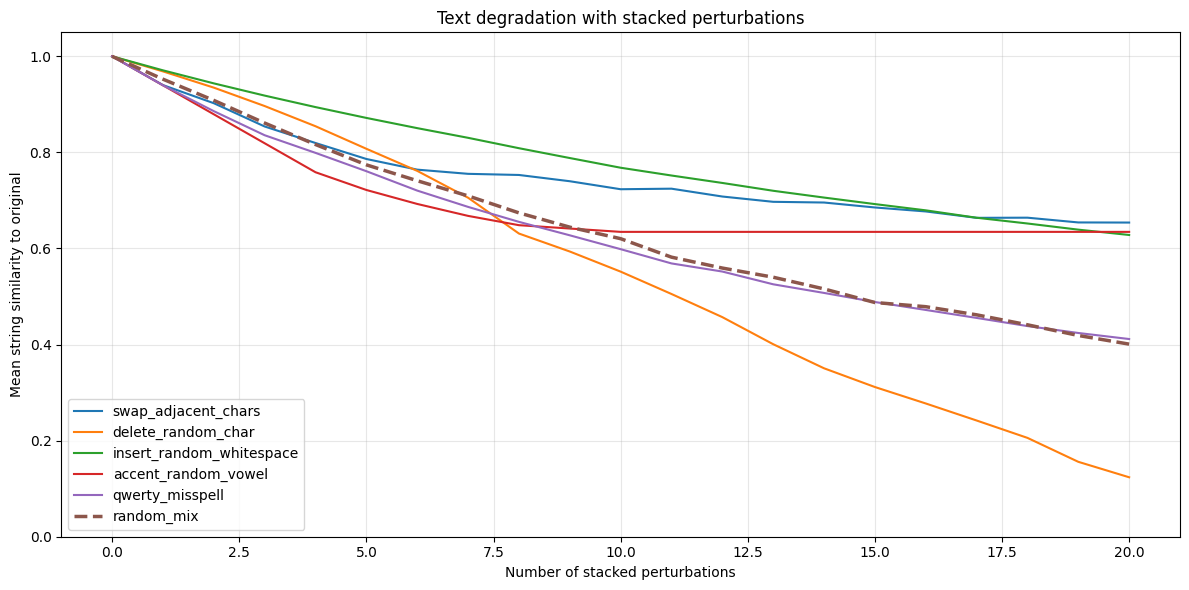

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = list(range(max_stacks + 1))
for name in results:
    means = [sum(results[name][k]) / len(results[name][k]) for k in x]
    style = "-" if name != "random_mix" else "--"
    linewidth = 2.5 if name == "random_mix" else 1.5
    ax.plot(x, means, style, label=name, linewidth=linewidth)

ax.set_xlabel("Number of stacked perturbations")
ax.set_ylabel("Mean string similarity to original")
ax.set_title("Text degradation with stacked perturbations")
ax.legend(loc="lower left")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Similarity distribution at key stack depths

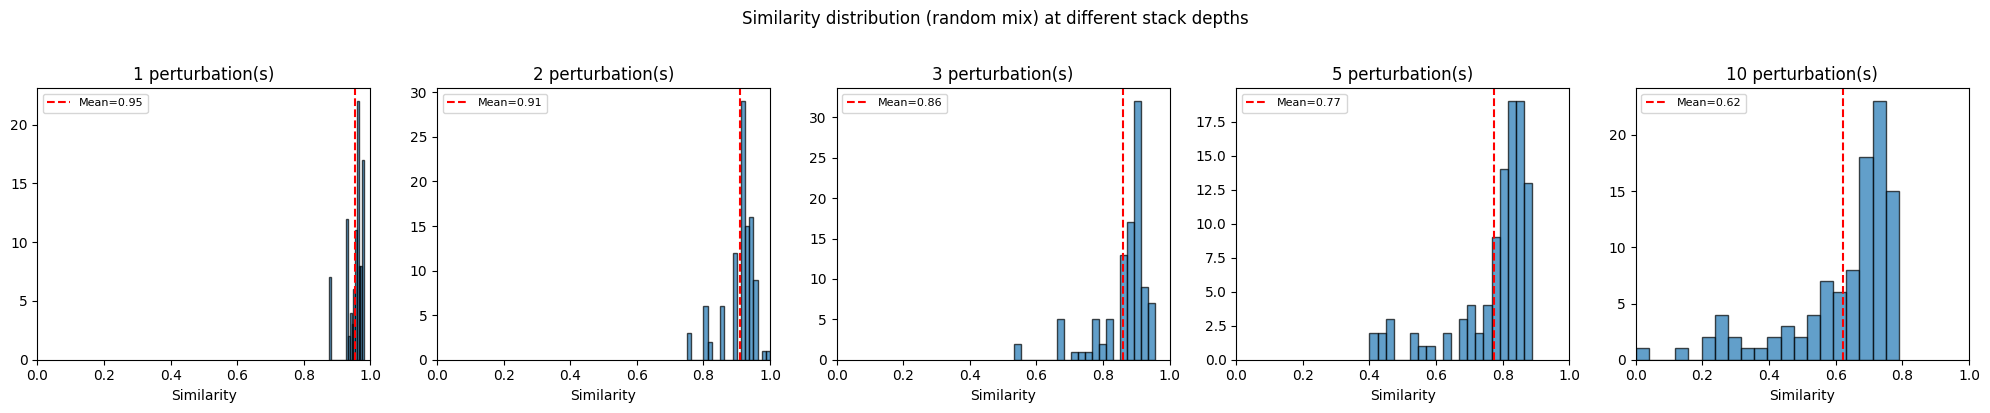

In [7]:
stack_depths = [1, 2, 3, 5, 10]

fig, axes = plt.subplots(1, len(stack_depths), figsize=(4 * len(stack_depths), 4))

for idx, depth in enumerate(stack_depths):
    sims = results["random_mix"][depth]
    axes[idx].hist(sims, bins=20, edgecolor="black", alpha=0.7)
    axes[idx].set_title(f"{depth} perturbation(s)")
    axes[idx].set_xlabel("Similarity")
    axes[idx].set_xlim(0, 1)
    axes[idx].axvline(sum(sims)/len(sims), color="red", linestyle="--",
                      label=f"Mean={sum(sims)/len(sims):.2f}")
    axes[idx].legend(fontsize=8)

plt.suptitle("Similarity distribution (random mix) at different stack depths", y=1.02)
plt.tight_layout()
plt.show()

## Pairwise perturbation stacking comparison

Which pairs of perturbations are worst/safest to combine?

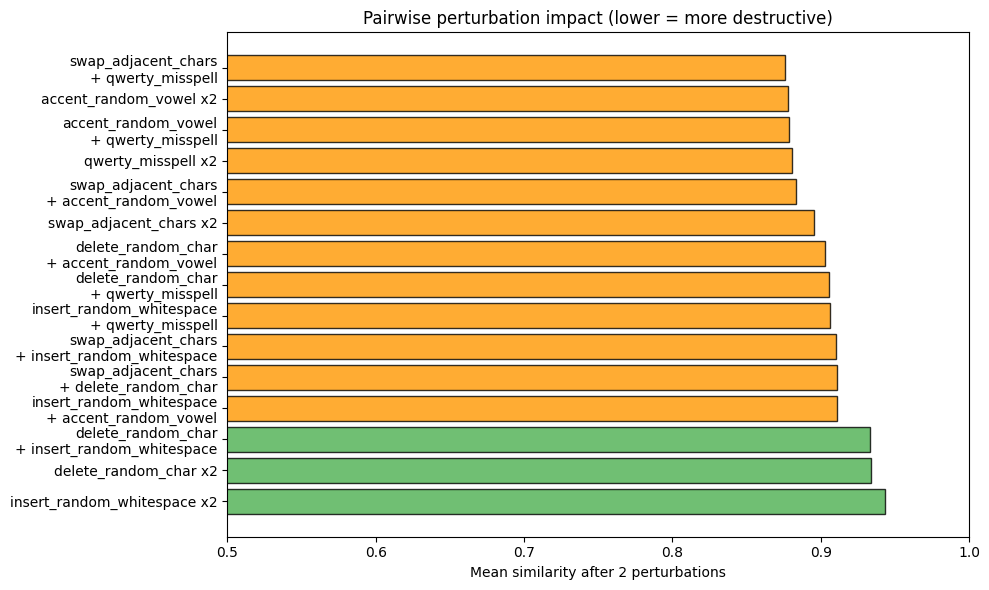

In [8]:
pair_results = {}
names = list(PERTURBATIONS.keys())

for i, name_a in enumerate(names):
    for name_b in names[i:]:
        fn_a = PERTURBATIONS[name_a]
        fn_b = PERTURBATIONS[name_b]
        sims = []
        for _ in range(200):
            text = random.choice(SAMPLE_TEXTS)
            perturbed = fn_b(fn_a(text))
            sims.append(SequenceMatcher(None, text, perturbed).ratio())
        pair_key = f"{name_a}\n+ {name_b}" if name_a != name_b else name_a + " x2"
        pair_results[pair_key] = sum(sims) / len(sims)

# Sort by similarity (worst combos first)
sorted_pairs = sorted(pair_results.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6))
pair_names = [p[0] for p in sorted_pairs]
pair_sims = [p[1] for p in sorted_pairs]
colors = ["#d32f2f" if s < 0.85 else "#ff9800" if s < 0.92 else "#4caf50" for s in pair_sims]
ax.barh(pair_names, pair_sims, color=colors, edgecolor="black", alpha=0.8)
ax.set_xlabel("Mean similarity after 2 perturbations")
ax.set_title("Pairwise perturbation impact (lower = more destructive)")
ax.set_xlim(0.5, 1.0)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Length change analysis

Some perturbations change string length (delete, insert whitespace). How much?

C:\Users\edlun\AppData\Local\Temp\ipykernel_22932\1511280830.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(length_changes.values(), labels=length_changes.keys(), vert=True)


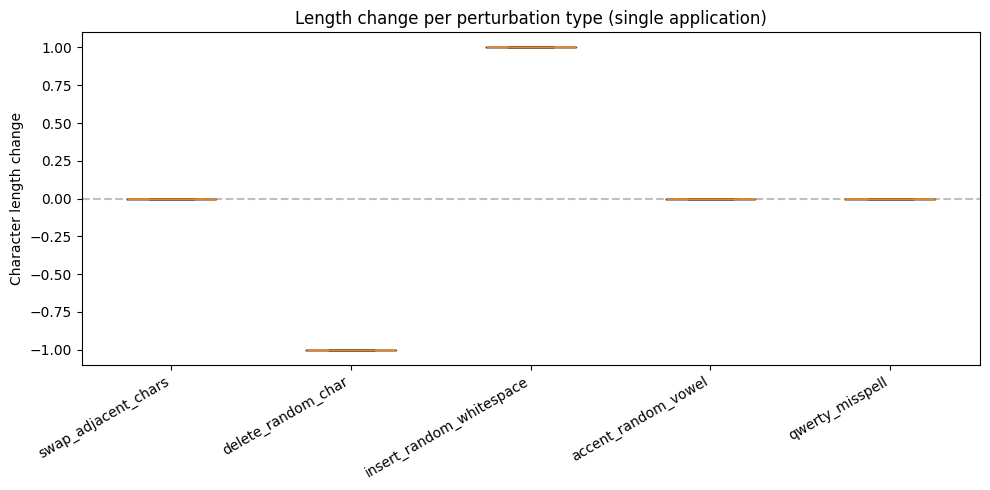

In [9]:
length_changes = {name: [] for name in PERTURBATIONS}

for _ in range(500):
    text = random.choice(SAMPLE_TEXTS)
    for name, fn in PERTURBATIONS.items():
        result = fn(text)
        length_changes[name].append(len(result) - len(text))

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(length_changes.values(), labels=length_changes.keys(), vert=True)
ax.set_ylabel("Character length change")
ax.set_title("Length change per perturbation type (single application)")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Recommendations

Based on the above analysis, summarize:
- Safe `perturbations_per_sample` values
- Which perturbations to prefer/avoid for upsampling
- Whether stacking is viable at all for our use case

In [10]:
print("Summary of mean similarity after N random-mix perturbations:")
print(f"{'N':>3}  {'Mean sim':>10}  {'Min sim':>10}")
for k in [1, 2, 3, 5, 10]:
    sims = results["random_mix"][k]
    print(f"{k:3d}  {sum(sims)/len(sims):10.3f}  {min(sims):10.3f}")

print("\nGuideline: perturbations_per_sample=1 is safest.")
print("perturbations_per_sample=2 still retains >90% similarity on average.")
print("Beyond 3 stacked perturbations, text can become noticeably garbled.")

Summary of mean similarity after N random-mix perturbations:
  N    Mean sim     Min sim
  1       0.952       0.875
  2       0.908       0.750
  3       0.861       0.533
  5       0.774       0.400
 10       0.620       0.000

Guideline: perturbations_per_sample=1 is safest.
perturbations_per_sample=2 still retains >90% similarity on average.
Beyond 3 stacked perturbations, text can become noticeably garbled.
